In [ ]:
#import all libraries set device and random seed
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time
import os
import copy
import pandas as pd
from torchvision.transforms.functional import to_pil_image
#set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)


device: cuda


In [ ]:
#define the image transform and downloading the dataset (train/resize,mean,std normalization)

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


# download dataset and perform transform
#set folder to store data
DATA_ROOT = "/content/data"
#load training data
train_data = datasets.OxfordIIITPet(root=DATA_ROOT, split='trainval', target_types='category',
                                        download=True, transform=data_transforms['train'])
#load test data
test_data = datasets.OxfordIIITPet(root=DATA_ROOT, split='test', target_types='category',
                                    download=True, transform=data_transforms['test'])
#list classnames(breeds)
class_names = train_data.classes
print(f"Classes(breeds) ({len(class_names)}): {class_names}")

100%|██████████| 792M/792M [00:20<00:00, 39.1MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 12.7MB/s]


Classes(breeds) (37): ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']


In [ ]:
#split training/validationtest split 85/15 data
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

train_indices, val_indices = train_test_split(
    range(len(train_data)), test_size=0.15, random_state=RANDOM_SEED
)
val_data = Subset(train_data, val_indices)
train_data = Subset(train_data, train_indices)


In [ ]:
#put train/val/test data in dataloaders
batch_size=32 #images proccessed together in one pass
dataloaders = {
    'train': DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2),
    'val':   DataLoader(val_data,   batch_size=batch_size, shuffle=False, num_workers=2),
    'test':  DataLoader(test_data,  batch_size=batch_size, shuffle=False, num_workers=2),
}
dataset_sizes = {'train': len(train_data), 'val': len(val_data), 'test': len(test_data)}
print(dataset_sizes) #check data size after loading

{'train': 3128, 'val': 552, 'test': 3669}


This dataset has 3128 training images 552 validation and 3669 test images which about 85/15 trainval test split

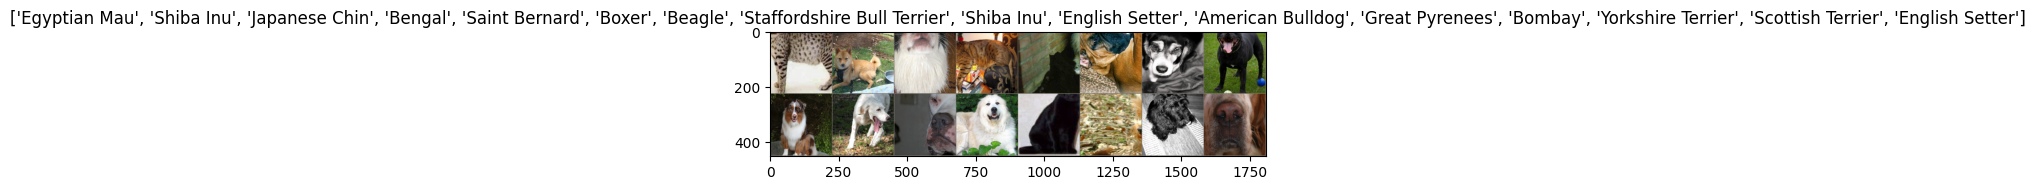

In [ ]:
#visualize dataset
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)



# Get a batch of training data
inputs, labels = next(iter(dataloaders['train']))

# grid layout for batch
out = torchvision.utils.make_grid(inputs[:16])

imshow(out, title=[class_names[l] for l in labels[:16]])

In [ ]:
#load ResNet18 change layer to output 37 classes for this dataset
model_ft = models.resnet18(pretrained=True)
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, len(class_names))
model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# make sure that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)
#look at hyperparameters
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 159MB/s]


In [ ]:
#set up the model training function
def train_model(model, criterion, optimizer, scheduler, num_epochs=20, patience=3):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    best_val_loss = float('inf')
    epochs_no_improve = 0
    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)
        # epoch training and validation
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()
            running_loss = 0.0
            running_corrects = 0

            # repeat over data
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                # track history on training data
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # looking at loss
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))
#early stopping setup

            if phase == 'val':
                if epoch_acc > best_acc:
                    best_acc = epoch_acc #store val acc balue
                    best_model_wts = copy.deepcopy(model.state_dict())

#check if val accuracy improved if improved stop if not keep going
                if epoch_loss < best_val_loss - 1e-4:
                    best_val_loss = epoch_loss
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1

        print()

        if epochs_no_improve >= patience:
            print(f'Early stopping after epoch {epoch} ')
            break

    time_passed = time.time() - since
    print(time_passed) #how long it took to get best val acc
    print('Best validation Accuracy is: {:4f}'.format(best_acc))

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model

In [ ]:
#run training function
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=20, patience=3)

Epoch 0/19
----------
train Loss: 0.4875 Acc: 0.8776
val Loss: 0.5388 Acc: 0.8351

Epoch 1/19
----------
train Loss: 0.4907 Acc: 0.8696
val Loss: 0.5358 Acc: 0.8297

Epoch 2/19
----------
train Loss: 0.4939 Acc: 0.8747
val Loss: 0.5547 Acc: 0.8333

Epoch 3/19
----------
train Loss: 0.5000 Acc: 0.8750
val Loss: 0.5342 Acc: 0.8587

Epoch 4/19
----------
train Loss: 0.4893 Acc: 0.8760
val Loss: 0.5654 Acc: 0.8370

Epoch 5/19
----------
train Loss: 0.4874 Acc: 0.8811
val Loss: 0.5170 Acc: 0.8424

Epoch 6/19
----------
train Loss: 0.4906 Acc: 0.8804
val Loss: 0.5106 Acc: 0.8551

Epoch 7/19
----------
train Loss: 0.5078 Acc: 0.8699
val Loss: 0.5398 Acc: 0.8442

Epoch 8/19
----------
train Loss: 0.4776 Acc: 0.8772
val Loss: 0.4811 Acc: 0.8714

Epoch 9/19
----------
train Loss: 0.4816 Acc: 0.8776
val Loss: 0.5259 Acc: 0.8478

Epoch 10/19
----------
train Loss: 0.5025 Acc: 0.8686
val Loss: 0.5873 Acc: 0.8170

Epoch 11/19
----------
train Loss: 0.4845 Acc: 0.8763
val Loss: 0.5797 Acc: 0.8152

Ea

Training stopped after 11 epochs because validation loss stopped improving for the set patience value which was 3 so earl stopping helped speed up the process

In [ ]:
#evaluate model
from sklearn.metrics import classification_report
model_ft.eval()
all_labels = []
all_preds = []
right=0
with torch.no_grad():
  #loop for getting all required values
    for inputs, labels in dataloaders['test']:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_ft(inputs)
        _, preds = torch.max(outputs, 1)
        right += (preds == labels).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100 * right / len(test_data) #get accuracy
print(f"Test Accuracy: {test_acc:.3f}%")
#print results
print(classification_report(all_labels, all_preds, target_names=class_names))

Test Accuracy: 90.433%
                            precision    recall  f1-score   support

                Abyssinian       0.88      0.93      0.90        98
          American Bulldog       0.70      0.89      0.78       100
 American Pit Bull Terrier       0.75      0.48      0.59       100
              Basset Hound       0.94      0.90      0.92       100
                    Beagle       0.88      0.93      0.90       100
                    Bengal       0.86      0.93      0.89       100
                    Birman       0.79      0.86      0.82       100
                    Bombay       0.91      0.95      0.93        88
                     Boxer       0.82      0.92      0.87        99
         British Shorthair       0.95      0.82      0.88       100
                 Chihuahua       0.87      0.90      0.88       100
              Egyptian Mau       0.92      0.93      0.92        97
    English Cocker Spaniel       0.89      0.94      0.91       100
            English Sett

90.08% test accuracy overall from the results its clear american pit bull and staffordshire terrier are the weakest classes reeasonable because they look very similar

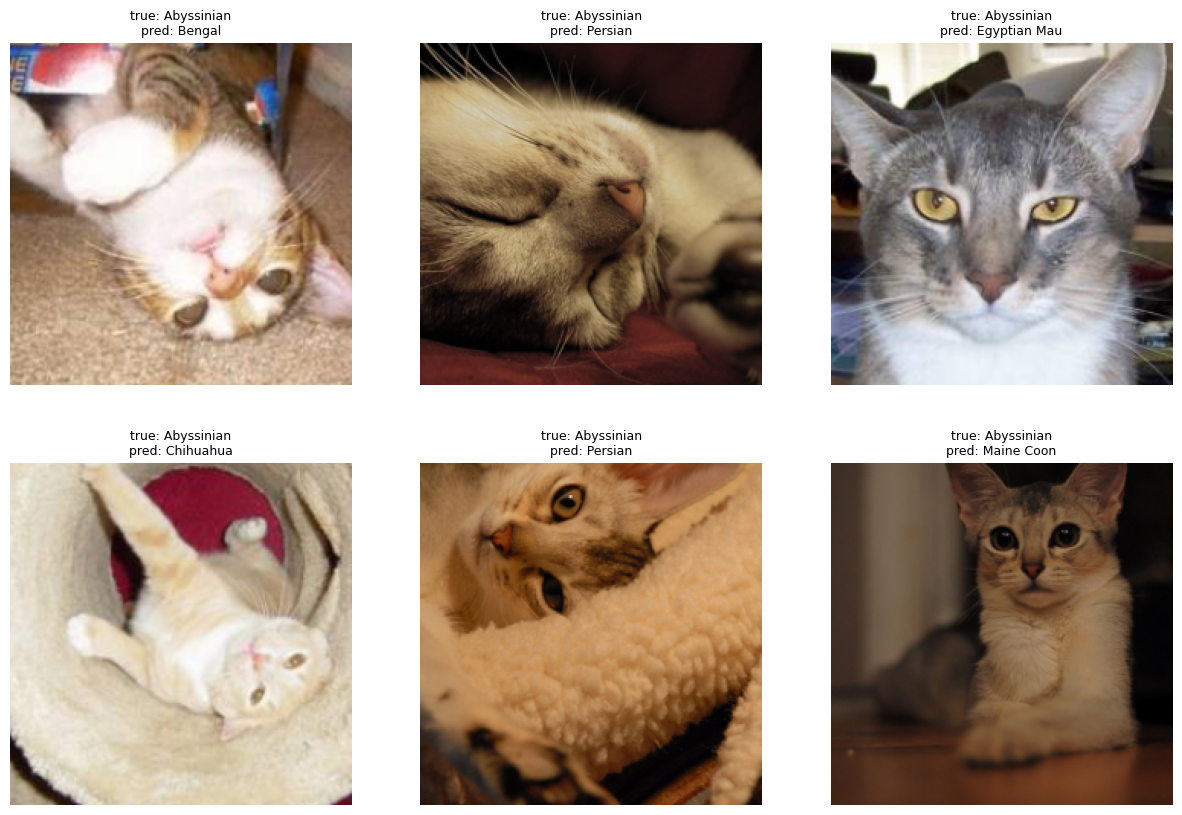

In [ ]:
#visulaize immages that got misclassified to understand mistakes
def show_misclassified(model, num_images=6):
    model.eval()
    shown = 0 #count
    fig = plt.figure(figsize=(15, 10))
#to get predictions
    with torch.no_grad(): #loop for test batches
        for inputs, labels in dataloaders['test']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            #check all images
            for j in range(inputs.size(0)):
                if preds[j] != labels[j] and shown < num_images: #to get only misclassified images
                    shown += 1
                    ax = plt.subplot(2, num_images // 2, shown)
                    ax.axis('off') #dont need axis turns it off
                    ax.set_title(f"true: {class_names[labels[j]]}\npred: {class_names[preds[j]]}", fontsize=9) #display text  predicted and actual
                    imshow(inputs.cpu().data[j])
            if shown >= num_images:
                break #stop scanning data

show_misclassified(model_ft) #call function

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 77.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires nump

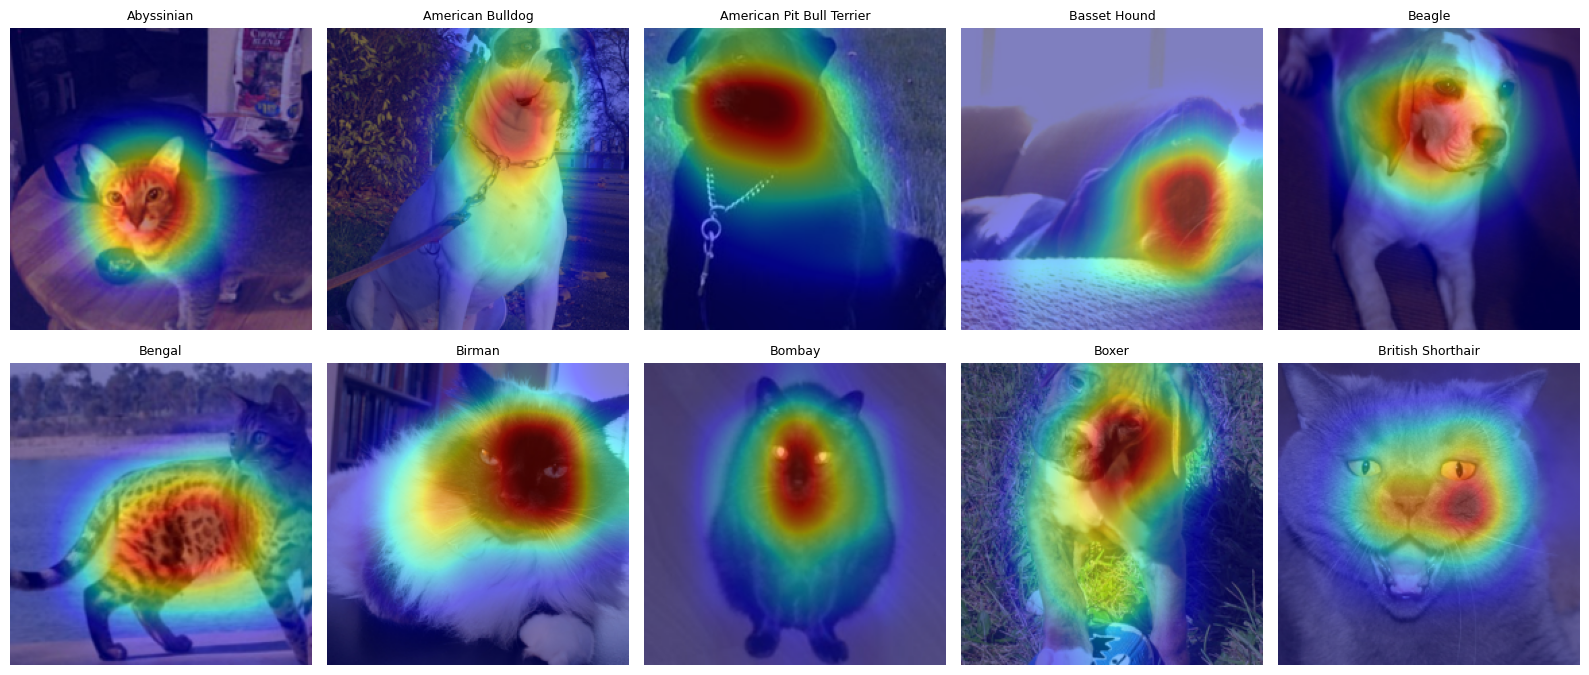

In [ ]:
#generate gradcam visulal
!pip install torchcam -q
from torchcam.methods import SmoothGradCAMpp
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image
model_ft.eval()  #evaluation mode
#avoid already shown examples scan images and show grad cam
set_classes=set()
cam_extractor = SmoothGradCAMpp(model_ft, target_layer='layer4') #connect to resnet18
fig, axs = plt.subplots(2, 5, figsize=(16, 7)) #set plot size
for inputs, labels in dataloaders['test']:
    for j in range(inputs.size(0)):
        label = labels[j].item()
        if label in set_classes:
            continue
        set_classes.add(label)
        img_tensor = inputs[j].unsqueeze(0).to(device)
        out = model_ft(img_tensor)
        activation_map = cam_extractor(out.squeeze(0).argmax().item(), out)
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        unnorm = (inputs[j].cpu() * std + mean).clamp(0, 1)
        result = overlay_mask(to_pil_image(unnorm), to_pil_image(activation_map[0].squeeze(0).cpu(), mode='F'), alpha=0.5)
        ax = axs[len(set_classes)//5 - (1 if len(set_classes)%5==0 else 0)][ (len(set_classes)-1) % 5]
        ax.imshow(result); ax.set_title(class_names[label], fontsize=9); ax.axis('off')
        if len(set_classes) == 10:
            break
    if len(set_classes) == 10:
        break
        #output
plt.tight_layout()
plt.show()
cam_extractor.remove_hooks()

In [ ]:
#ai generated breed info for all 37 breeds put into distonary
breed_info = {
    "Abyssinian": "Active, playful, and vocal. Medium size (3-5 kg). Needs daily interactive play; short coat needs only minimal weekly brushing.",
    "American Bulldog": "Confident, loyal, and strong. Large (30-45 kg). Needs substantial daily exercise; short coat, minimal grooming.",
    "American Pit Bull Terrier": "Loyal, affectionate, and energetic. Medium-large (14-27 kg). Needs high daily exercise; short coat, minimal grooming.",
    "Basset Hound": "Laid-back, friendly, and a bit stubborn. Medium (18-29 kg). Moderate exercise (prone to weight gain); long ears need regular cleaning.",
    "Beagle": "Curious, friendly, and scent-driven. Small-medium (9-11 kg). Needs high daily exercise; short coat, weekly brushing.",
    "Bengal": "Highly energetic, intelligent, and athletic. Medium-large (4-7 kg). Needs substantial daily exercise/enrichment; minimal grooming.",
    "Birman": "Gentle, affectionate, and calm. Medium (4-6 kg). Moderate play needs; semi-long coat, weekly brushing to prevent mats.",
    "Bombay": "Affectionate, social, and people-oriented. Medium (3-5 kg). Moderate exercise; short glossy coat, minimal grooming.",
    "Boxer": "Playful, energetic, and loyal. Large (25-32 kg). Needs high daily exercise; short coat, minimal grooming.",
    "British Shorthair": "Calm, easygoing, and independent. Medium-large (4-8 kg). Low-moderate exercise needs; dense coat, weekly brushing.",
    "Chihuahua": "Alert, bold, and loyal to its owner. Tiny (1.5-3 kg). Low-moderate exercise; minimal to weekly brushing depending on coat length.",
    "Egyptian Mau": "Athletic, alert, and loyal to family. Medium (3-5 kg). Needs high daily exercise; short coat, minimal grooming.",
    "English Cocker Spaniel": "Gentle, affectionate, and energetic. Medium (13-15 kg). Moderate-high exercise; silky coat needs regular brushing and ear care.",
    "English Setter": "Friendly, mellow, and active outdoors. Large (20-30 kg). Needs high daily exercise; feathered coat needs regular brushing.",
    "German Shorthaired": "Energetic, intelligent, and versatile. Large (20-32 kg). Needs very high daily exercise; short coat, minimal grooming.",
    "Great Pyrenees": "Calm, protective, and independent. Very large (39-54 kg). Moderate exercise; thick double coat sheds heavily, needs regular brushing.",
    "Havanese": "Friendly, playful, and adaptable. Small (4.5-7 kg). Moderate exercise; long silky coat needs frequent brushing.",
    "Japanese Chin": "Affectionate, quiet, and almost cat-like. Small (2-4.5 kg). Low exercise needs; silky coat needs regular brushing.",
    "Keeshond": "Friendly, alert, and people-oriented. Medium (16-20 kg). Moderate exercise; thick double coat sheds heavily, needs frequent brushing.",
    "Leonberger": "Gentle giant, friendly, and calm. Very large (45-77 kg). Moderate-high exercise; long dense coat needs frequent brushing.",
    "Maine Coon": "Gentle giant, friendly, and sociable. Large (5-9 kg). Moderate exercise; long coat needs brushing 2-3 times a week.",
    "Miniature Pinscher": "Fearless, energetic, and alert. Small (4-6 kg). Moderate-high exercise; short coat, minimal grooming.",
    "Newfoundland": "Gentle giant, sweet-natured, and calm. Very large (45-68 kg). Moderate exercise; thick coat needs frequent brushing, drools.",
    "Persian": "Quiet, sweet, and low-energy. Medium (3-5.5 kg). Low exercise needs; long coat needs daily brushing.",
    "Pomeranian": "Lively, bold, and vocal. Tiny (1.9-3.5 kg). Moderate exercise; thick double coat needs frequent brushing.",
    "Pug": "Charming, playful, and affectionate. Small (6-8 kg). Low-moderate exercise (prone to overheating); facial wrinkles need regular cleaning.",
    "Ragdoll": "Docile, affectionate, and relaxed. Large (4.5-9 kg). Low-moderate exercise; semi-long coat, weekly brushing.",
    "Russian Blue": "Reserved with strangers but loyal to family. Medium (3-5.5 kg). Moderate exercise; short dense coat, minimal grooming.",
    "Saint Bernard": "Gentle giant, patient, and calm. Very large (54-82 kg). Moderate exercise; coat needs regular brushing, drools.",
    "Samoyed": "Friendly, gentle, and vocal. Medium-large (16-30 kg). Needs high daily exercise; thick white coat sheds heavily, needs frequent brushing.",
    "Scottish Terrier": "Independent, confident, and dignified. Small (8.5-10 kg). Moderate exercise; wiry coat needs regular grooming/trimming.",
    "Shiba Inu": "Alert, independent, and spirited. Small-medium (8-11 kg). Moderate-high exercise; double coat sheds heavily, needs regular brushing.",
    "Siamese": "Vocal, social, and intelligent. Medium (3-5.5 kg). Needs high interactive play; short coat, minimal grooming.",
    "Sphynx": "Energetic, affectionate, and attention-seeking. Medium (3.5-5.5 kg). High play needs; hairless -- needs weekly skin bathing instead of brushing.",
    "Staffordshire Bull Terrier": "Affectionate, courageous, and great with people. Medium (11-17 kg). Needs high daily exercise; short coat, minimal grooming.",
    "Wheaten Terrier": "Friendly, happy, and energetic. Medium (14-20 kg). Moderate-high exercise; soft coat needs frequent brushing, low shedding.",
    "Yorkshire Terrier": "Bold, affectionate, and feisty. Tiny (2-3.2 kg). Moderate exercise; long silky coat needs frequent brushing or a trimmed 'puppy cut'.",
}
#look up function
def get_breed_info(breed_name):
    return breed_info.get(breed_name, "breed info not available f.")
comparison_loader = DataLoader(test_data, batch_size=32, shuffle=True, num_workers=2)

results = [] #store results
model_ft.eval()
sample_count = 0
#loop over all data check each image add batch dim connect to index
with torch.no_grad():
    for inputs, labels in comparison_loader:
        for j in range(inputs.size(0)):
            if sample_count >= 37:
                break
            img_tensor = inputs[j].unsqueeze(0).to(device)
            out = model_ft(img_tensor)
            pred_idx = out.argmax(dim=1).item()
            our_pred = class_names[pred_idx]
            true_label = class_names[labels[j].item()]
            ai_response = get_breed_info(our_pred)
            results.append({
                "true label": true_label,
                "our model pred": our_pred,
                "our model correct": our_pred == true_label,
                "ai care info": ai_response
            })
            sample_count += 1
        if sample_count >= 37:
            break
            #display results

results_df = pd.DataFrame(results)
results_df

,true label,our model pred,our model correct,ai care info
0,Wheaten Terrier,Wheaten Terrier,True,"Friendly, happy, and energetic. Medium (14-20 ..."
1,Persian,Ragdoll,False,"Docile, affectionate, and relaxed. Large (4.5-..."
2,Great Pyrenees,Great Pyrenees,True,"Calm, protective, and independent. Very large ..."
3,Chihuahua,American Bulldog,False,"Confident, loyal, and strong. Large (30-45 kg)..."
4,Abyssinian,Abyssinian,True,"Active, playful, and vocal. Medium size (3-5 k..."
5,American Pit Bull Terrier,American Bulldog,False,"Confident, loyal, and strong. Large (30-45 kg)..."
6,Sphynx,Sphynx,True,"Energetic, affectionate, and attention-seeking..."
7,Pug,Pug,True,"Charming, playful, and affectionate. Small (6-..."
8,Newfoundland,Newfoundland,True,"Gentle giant, sweet-natured, and calm. Very la..."
9,Saint Bernard,Saint Bernard,True,"Gentle giant, patient, and calm. Very large (5..."


Looking at the samples results 30 out 37 predicted correctly misclassifiesd pitbull and similar this is due the limtations of the data set

In [ ]:
#gradio dashboard
!pip install gradio -q
import gradio as gr

inference_transform = data_transforms['test']
LOW_CONFIDENCE_THRESHOLD = 0.40

def predict(image):
    model_ft.eval()
    img_tensor = inference_transform(image.convert('RGB')).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model_ft(img_tensor)
        probs = torch.nn.functional.softmax(outputs, dim=1)[0]
    return {class_names[i]: float(probs[i]) for i in range(len(class_names))}

def predict_with_care_info(image):
    if image is None:
        return {}, "Please upload an image."

    try:
        pred_probs = predict(image)
    except RuntimeError as e:
        # Most likely cause: leftover Grad-CAM hooks still attached to model_ft from an earlier cell.
        # Fix: run cam_extractor.remove_hooks() (see the Grad-CAM section above) and try again.
        return {}, f"Model prediction failed: {e}"

    top_breed = max(pred_probs, key=pred_probs.get)
    top_conf = pred_probs[top_breed]

    if top_conf < LOW_CONFIDENCE_THRESHOLD:
        note = (f"Low confidence ({top_conf:.0%}) -- this photo may not be one of the 37 known breeds, "
                "or may not be a cat/dog at all. The model always guesses one of its known breeds regardless.\n\n")
    else:
        note = ""

    care_info = get_breed_info(top_breed)
    return pred_probs, note + f"{top_breed}: {care_info}"

theme = gr.themes.Soft(
    primary_hue="orange",
    secondary_hue="slate",
    font=[gr.themes.GoogleFont("Inter"), "ui-sans-serif", "sans-serif"],
)

custom_css = """
#title-md h1 { margin-bottom: 0.2em; }
#subtitle-md p { color: #6b7280; margin-top: 0; }
.gradio-container { max-width: 900px !important; margin: auto !important; }
"""

with gr.Blocks(theme=theme, css=custom_css, title="Oxford-IIIT Pet Classifier") as demo:
    gr.Markdown("# \U0001F43E Oxford-IIIT Pet Breed Classifier", elem_id="title-md")
    gr.Markdown(
        "Upload a photo of a cat or dog and get a breed prediction across all 37 Oxford-IIIT Pet breeds, "
        "plus AI-generated breed care info. Predictions below 40% confidence are flagged, since the model "
        "always guesses one of its 37 known breeds even for photos outside that set.",
        elem_id="subtitle-md",
    )

    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(type="pil", label="Upload a pet photo", height=320)
            submit_btn = gr.Button("Classify Breed", variant="primary")
        with gr.Column(scale=1):
            label_output = gr.Label(num_top_classes=5, label="Model Prediction")
            care_output = gr.Textbox(label="AI Breed Care Info", lines=5)

    submit_btn.click(fn=predict_with_care_info, inputs=image_input, outputs=[label_output, care_output])
    image_input.change(fn=predict_with_care_info, inputs=image_input, outputs=[label_output, care_output])

demo.launch(share=True)

/tmp/ipykernel_1007/3107890525.py:51: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=theme, css=custom_css, title="Oxford-IIIT Pet Classifier") as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bb24d80c4e9d0897db.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Conclusion:

In conclusion my goal was to build a deep learning model that is able to tell a pet’s breed from a photo using athe dataset Oxford-IIIT Pet dataset which has data 37 breeds. I also wanted to connect the model’s prediction to I ai generated information to make the final result more useful. Overall, my goal was achieved. The final model reached a 90.43% test accuracy, with precision, recall, and F1 scores all around 0.90, using 3669 test images that was not used during training or validation. The results also showed that the model’s mistakes were not completely random because It confused breeds that look very similar breeds like the American Pit Bull Terrier, Staffordshire Bull Terrier, and American Bulldog were commonly confused because they have similar body shapes, head shapes, and coats. The model also had difficulties with similar long haired cat breeds such like Persian, Birman, Maine Coon, and Ragdoll. Using all 37 breeds made it possible to identify these patterns, which may not have appeared with a smaller 10 or 20 class datasets. The use of early stoppage helped the model stop when it reached the best accuracy to prevent it from overfitting and to give us the best results. From the Grad CAM visualizations I was able to see that the model was focusing on the animals instead of the background or other unrelated parts. This might be why many of the model’s mistakes happened because some breeds genuinely look similar rather than because the model was focusing on the wrong parts of the images. A limitation is that the oxford IIIT pet dataset is from a single source and has only 7349 training images. That is why the model can preform differently on photos taken with different cameras, backgrounds, lighting, or environments. However even with these limitations  the model provides a strong starting point that could be improved in the future using a larger and a dataset that is varied more.
